In [1]:
import os
from PIL import Image, ImageOps
import numpy as np
from pathlib import Path
import re

# ============================================================
# DATA PREPROCESSING APPROACH - Phase2 with Center Cropping
# ============================================================
# Camera: ESP32-S3 OV2640 captures 160x120 (QQVGA) images
# Cropping: Center crop to ~106x94 (removes edges, focuses on hand)
#   - Left: 17% crop (27px from left)
#   - Right: 83% crop (27px from right)  
#   - Top/Bottom: 13px crop each side
# Resize: Cropped region -> 64x64 for model input
# This matches production preprocessing on ESP32 and reduces distortion
# ============================================================

# Get all image files from Phase2 directory
image_dir = Path('Phase3')
image_files = sorted(image_dir.glob('*.jpg'))

# Dictionary to track counts for each label
label_counts = {}

# Lists to store images and labels
images = []
y = []

# Load images and create labels
for img_path in image_files:
    # Extract label name from filename (everything before the last underscore and number)
    filename = img_path.stem  # Get filename without extension
    # Find the label name (everything before the last underscore)
    match = re.match(r'^(.+?)_\d+$', filename)
    if match:
        label_name = match.group(1).lower()  # Convert to lowercase
        
        # Initialize counter for this label if not seen before
        if label_name not in label_counts:
            label_counts[label_name] = 0
        
        label_counts[label_name] += 1
        
        # Use just the label name (no underscore and index)
        label = label_name
        
        # Load image
        img = Image.open(img_path)
        images.append(img)
        y.append(label)

print(f"Loaded {len(images)} images")
print(f"Unique label types: {list(label_counts.keys())}")
print(f"Label counts: {label_counts}")
print(f"\nFirst few labels: {y[:5]}")



Loaded 1496 images
Unique label types: ['closed_hand', 'none', 'open_hand']
Label counts: {'closed_hand': 500, 'none': 498, 'open_hand': 498}

First few labels: ['closed_hand', 'closed_hand', 'closed_hand', 'closed_hand', 'closed_hand']


In [2]:
import matplotlib.pyplot as plt

def plot_image(image):
    # Convert PIL image to numpy array if needed
    if isinstance(image, Image.Image):
        image = np.array(image)
    
    # Determine if grayscale or color
    if len(image.shape) == 2 or image.shape[2] == 1:
        # Grayscale image
        plt.imshow(image, cmap='gray')
    else:
        # Color image
        plt.imshow(image)
    plt.axis('off')
    plt.show()

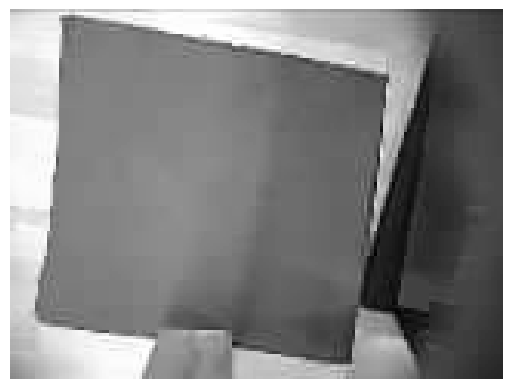

In [ ]:
grayscale_images = [ImageOps.grayscale(img) for img in images]
plot_image(grayscale_images[700])

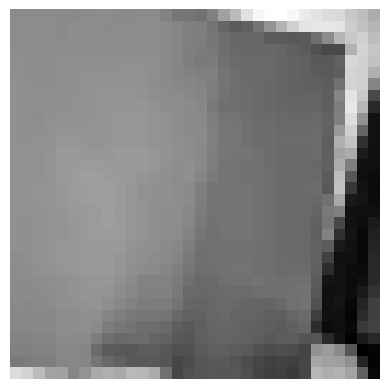

In [5]:
def crop_and_resize(img, final_size=(64, 64)):
    """
    Crop and resize image to match ESP32 camera preprocessing.
    
    For 160x120 images (QQVGA):
    - Crops to ~106x94 (center region, removes edge artifacts)
    - Resizes to 64x64 for model input
    
    This prevents distortion and focuses on the hand gesture region.
    """
    w, h = img.size
    # Calculate crop box (center crop to remove edges)
    left = int(w * 0.17)    # 27px from left (for 160px width)
    right = int(w * 0.83)   # 27px from right (133px)
    top = 13                # 13px from top
    bottom = h - 13         # 13px from bottom (107px for 120px height)
    
    # Ensure valid crop coordinates
    left = max(0, left)
    right = min(w, right)
    top = max(0, top)
    bottom = min(h, bottom)
    
    # Crop and resize
    img_cropped = img.crop((left, top, right, bottom))
    img_resized = img_cropped.resize(final_size, Image.BICUBIC)
    return img_resized

# Example usage:
cropped_img = crop_and_resize(grayscale_images[700], final_size=(32, 32))
plot_image(cropped_img)


In [6]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# CRITICAL: Split BEFORE preprocessing to avoid data leakage!
# Convert labels to numpy array for splitting
y_labels = np.array(y)

# Encode string labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

# Split the RAW images and labels FIRST (before any preprocessing)
images_train, images_test, y_train_encoded, y_test_encoded = train_test_split(
    images, y_encoded, 
    test_size=0.2, 
    random_state=42,
    shuffle=True,  # Shuffle to avoid temporal leakage from sorted filenames
    stratify=y_encoded  # Maintain class distribution in train/test
)

print(f"Train size: {len(images_train)}, Test size: {len(images_test)}")
print(f"Unique classes in train: {np.unique(y_train_encoded)}")
print(f"Unique classes in test: {np.unique(y_test_encoded)}")

# NOW process train and test sets SEPARATELY
def preprocess_images(img_list):
    """Process images: grayscale, crop, resize, normalize"""
    processed = []
    for x in img_list:
        x = ImageOps.grayscale(x)
        x = crop_and_resize(x, final_size=(32, 32))  # Use new cropping function
        x = np.array(x, dtype=np.float32) / 255.0  # normalize to [0, 1]
        processed.append(x)
    return np.stack(processed)

# Process train set
X_train = preprocess_images(images_train)
X_train = torch.from_numpy(X_train).unsqueeze(1)  # (N, 1, 64, 64)
y_train = torch.from_numpy(y_train_encoded).long()

# Process test set (using same preprocessing steps, but separate processing)
X_test = preprocess_images(images_test)
X_test = torch.from_numpy(X_test).unsqueeze(1)  # (N, 1, 64, 64)
y_test = torch.from_numpy(y_test_encoded).long()

print(f"\nX_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Create data loaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)


Train size: 1196, Test size: 300
Unique classes in train: [0 1 2]
Unique classes in test: [0 1 2]

X_train shape: torch.Size([1196, 1, 32, 32]), y_train shape: torch.Size([1196])
X_test shape: torch.Size([300, 1, 32, 32]), y_test shape: torch.Size([300])


In [7]:

import torch.nn as nn
import torch.nn.functional as F

class HandNet100k(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 1x64x64 -> 32x32x32 now 1x32x32 -> 16x16x16
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2: 32x32x32 -> 64x16x16 now 16x16x16 -> 32x8x8
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: 32x8x8 -> 64x8x8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # Reduce spatial dims to 1x1
            nn.AdaptiveAvgPool2d(1),
        )

        # Final classifier: 64 -> 3
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # B x 64
        return self.classifier(x)



# Instantiate model, loss, and optimizer
mod = HandNet100k()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mod.parameters(), lr=0.001)

# Fix: Use the correct DataLoader variable names
n_epochs = 10
mod.train()
for epoch in range(n_epochs):
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = mod(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {total_loss/len(train_loader):.4f}")

mod.eval()
correct = 0
total = 0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = mod(batch_X)
        _, predicted = outputs.max(1)
        correct += predicted.eq(batch_y).sum().item()
        total += batch_y.size(0)

print(f"Accuracy of the model on the {total} test images: {100 * correct / total:.2f}%")

Epoch 1/10, Loss: 0.4482
Epoch 2/10, Loss: 0.1144
Epoch 3/10, Loss: 0.0556
Epoch 4/10, Loss: 0.0329
Epoch 5/10, Loss: 0.0209
Epoch 6/10, Loss: 0.0182
Epoch 7/10, Loss: 0.0127
Epoch 8/10, Loss: 0.0089
Epoch 9/10, Loss: 0.0070
Epoch 10/10, Loss: 0.0053
Accuracy of the model on the 300 test images: 100.00%


In [8]:
# Save only the weights of the model (state_dict)
torch.save(mod.state_dict(), 'phase2_cropped_weights.pth')

# Print the size of the weights file
import os
weights_size = os.path.getsize('phase2_cropped_weights.pth')
print(f"Saved weights file 'phase2_cropped_weights.pth' size: {weights_size} bytes")

# Estimate the full model size for an ESP32:
# ESP32 typically requires quantized/int8 weights, but here we will show the PyTorch weight size
print(f"Estimated model size on ESP32 (without PyTorch overhead; weights only): {weights_size} bytes")



Saved weights file 'phase2_cropped_weights.pth' size: 104145 bytes
Estimated model size on ESP32 (without PyTorch overhead; weights only): 104145 bytes


In [9]:
# 1. Recreate and load weights
model = HandNet100k(num_classes=3)
state = torch.load("phase2_cropped_weights.pth", map_location="cpu")
model.load_state_dict(state)
model.eval()

# 2. Export to ONNX
dummy = torch.randn(1, 1, 32, 32)  # batch=1, 1x32x32 grayscale
onnx_path = "handnet_fp32.onnx"

torch.onnx.export(
    model,
    dummy,
    onnx_path,
    input_names=["input"],
    output_names=["logits"],
    opset_version=13,
    do_constant_folding=True,
)
print("Exported to", onnx_path)

W1206 13:57:47.995000 27272 Lib\site-packages\torch\onnx\_internal\exporter\_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W1206 13:57:49.016000 27272 Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::nms


[torch.onnx] Obtain model graph for `HandNet100k([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `HandNet100k([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 13).
Failed to convert the model to the target version 13 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Users\austi\SpotifyGesture\HandSignalDetection\Model_Training\.venv\Lib\site-packages\onnxscript\version_converter\__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\austi\SpotifyGesture\HandSignalDetection\Model_Training\.venv\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "c:\Users\austi\SpotifyGesture\HandSignalDetection\Model_Training\.venv\Lib\site-packages\onnxscript\version_converter\__init__.py", line 122, in _partial_convert_version
    return onnx.version_conve

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 3 of general pattern rewrite rules.
Exported to handnet_fp32.onnx


In [10]:
from onnxruntime.quantization import quantize_dynamic, QuantType
import onnx

fp32_model = "handnet_fp32.onnx"
int8_model = "handnet_int8.onnx"

# Load ONNX and strip shape info problems
model = onnx.load(fp32_model)

# Disable shape inference by removing all ValueInfo protobufs
# (this prevents ORT from trying to reconcile shapes during quantization)
model.graph.value_info.clear()

onnx.save(model, "tmp_no_shinfo.onnx")

quantize_dynamic(
    model_input="tmp_no_shinfo.onnx",
    model_output=int8_model,
    weight_type=QuantType.QInt8,
    op_types_to_quantize=["Conv", "Gemm", "MatMul"],  # only ops that have weights
    use_external_data_format=False                    # keep everything in one file
)

print("Saved quantized model to", int8_model)


Saved quantized model to handnet_int8.onnx


In [11]:
import os
import numpy as np
import onnxruntime as ort
import torch

fp32_model_path = "handnet_fp32.onnx"
int8_model_path = "handnet_int8.onnx"

# 1. Print sizes
fp32_size = os.path.getsize(fp32_model_path)
int8_size = os.path.getsize(int8_model_path)
print(f"FP32 ONNX model size: {fp32_size} bytes")
print(f"INT8 ONNX model size: {int8_size} bytes")

# 2. Helper: evaluate an ONNX model that expects batch_size=1
def eval_onnx_batch1(model_path, test_loader):
    session = ort.InferenceSession(model_path, providers=["CPUExecutionProvider"])
    input_name = session.get_inputs()[0].name
    output_name = session.get_outputs()[0].name

    correct = 0
    total = 0

    for batch_X, batch_y in test_loader:
        # Loop over samples so each input has shape [1, 1, 64, 64]
        for x, y in zip(batch_X, batch_y):
            x_np = x.unsqueeze(0).cpu().numpy().astype(np.float32)  # [1, 1, 64, 64]
            logits = session.run([output_name], {input_name: x_np})[0]  # [1, 6]
            pred = int(logits.argmax(axis=1)[0])
            correct += int(pred == int(y.item()))
            total += 1

    acc = 100.0 * correct / total
    return acc

# 3. Try quantized model first (will fail due to ConvInteger kernel)
try:
    quant_session = ort.InferenceSession(int8_model_path, providers=["CPUExecutionProvider"])
    print("Quantized model loaded successfully, but this environment lacks ConvInteger kernels so we won't evaluate it here.")
except Exception as e:
    print("Cannot run quantized model in this onnxruntime build:")
    print(repr(e))

# 4. Evaluate FP32 ONNX model (this should work)
try:
    fp32_acc = eval_onnx_batch1(fp32_model_path, test_loader)
    print(f"FP32 ONNX model accuracy on {len(test_loader.dataset)} test images: {fp32_acc:.2f}%")
except Exception as e2:
    print("FP32 ONNX inference failed:")
    print(repr(e2))


FP32 ONNX model size: 13288 bytes
INT8 ONNX model size: 38214 bytes
Cannot run quantized model in this onnxruntime build:
NotImplemented("[ONNXRuntimeError] : 9 : NOT_IMPLEMENTED : Could not find an implementation for ConvInteger(10) node with name 'node_Conv_21_quant'")
FP32 ONNX model accuracy on 300 test images: 100.00%


TF LIte

In [12]:
import numpy as np
from PIL import ImageOps
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# images: list of PIL.Image
# y: list of string labels

y_labels = np.array(y)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)
num_classes = len(label_encoder.classes_)
print("Classes:", list(label_encoder.classes_))
print("Num classes:", num_classes)

# Split before preprocessing
images_train, images_test, y_train_encoded, y_test_encoded = train_test_split(
    images,
    y_encoded,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_encoded,
)

print(f"Train size: {len(images_train)}, Test size: {len(images_test)}")
print(f"Unique classes in train: {np.unique(y_train_encoded)}")
print(f"Unique classes in test: {np.unique(y_test_encoded)}")

def preprocess_images(img_list):
    processed = []
    for x in img_list:
        x = ImageOps.grayscale(x)
        x = crop_and_resize(x, final_size=(32, 32))  # Use new cropping function
        x = np.array(x, dtype=np.float32) / 255.0  # [H, W] in [0,1]
        processed.append(x)
    return np.stack(processed)

X_train = preprocess_images(images_train)  # (N, 32, 32)
X_test  = preprocess_images(images_test)   # (N, 32, 32)

y_train = np.array(y_train_encoded, dtype=np.int64)
y_test  = np.array(y_test_encoded, dtype=np.int64)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Keras expects NHWC: (N, 32, 32, 1)
X_train_keras = X_train[..., np.newaxis]
X_test_keras  = X_test[..., np.newaxis]

print("X_train_keras shape:", X_train_keras.shape)
print("X_test_keras shape:", X_test_keras.shape)


Classes: [np.str_('closed_hand'), np.str_('none'), np.str_('open_hand')]
Num classes: 3
Train size: 1196, Test size: 300
Unique classes in train: [0 1 2]
Unique classes in test: [0 1 2]
X_train shape: (1196, 32, 32), y_train shape: (1196,)
X_test shape: (300, 32, 32), y_test shape: (300,)
X_train_keras shape: (1196, 32, 32, 1)
X_test_keras shape: (300, 32, 32, 1)


In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_handnet_keras(num_classes, input_shape=(32, 32, 1)):
    inputs = keras.Input(shape=input_shape)

    # Block 1: 1x32x32 -> 8x16x16
    x = layers.Conv2D(
        8,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
    )(inputs)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5)(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)  # 16x16

    # Block 2: 8x16x16 -> 16x8x8
    x = layers.Conv2D(
        16,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
    )(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5)(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)  # 8x8

    # Block 3: 16x8x8 -> 32x8x8
    x = layers.Conv2D(
        32,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
    )(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5)(x)
    x = layers.ReLU()(x)

    # AdaptiveAvgPool2d(1) == GlobalAveragePooling2D
    x = layers.GlobalAveragePooling2D()(x)         # -> 32

    # Classifier: 32 -> num_classes (logits)
    outputs = layers.Dense(num_classes, activation=None)(x)

    model = keras.Model(inputs, outputs, name="HandNet100k_Keras")
    return model

model = build_handnet_keras(num_classes=num_classes, input_shape=(32, 32, 1))
model.summary()


Model: "HandNet100k_Keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 8)      │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 16)     │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 32)       │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,155 (24.04 KB)

 Trainable params: 6,043 (23.61 KB)

 Non-trainable params: 112 (448.00 B)

Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7166 - loss: 0.7266 - val_accuracy: 0.8933 - val_loss: 0.4239
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9875 - loss: 0.2056 - val_accuracy: 0.9800 - val_loss: 0.1825
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9941 - loss: 0.1106 - val_accuracy: 0.9967 - val_loss: 0.0770
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9983 - loss: 0.0765 - val_accuracy: 0.9967 - val_loss: 0.0821
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9967 - loss: 0.0591 - val_accuracy: 1.0000 - val_loss: 0.0480
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9983 - loss: 0.0400 - val_accuracy: 1.0000 - val_loss: 0.0288
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9983 - loss: 0.0347 - val_accuracy: 1.0000 - val_loss: 0.0292
Epoch 8/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9992 - loss: 0.0264 - val_accuracy: 1.0000 - val_l

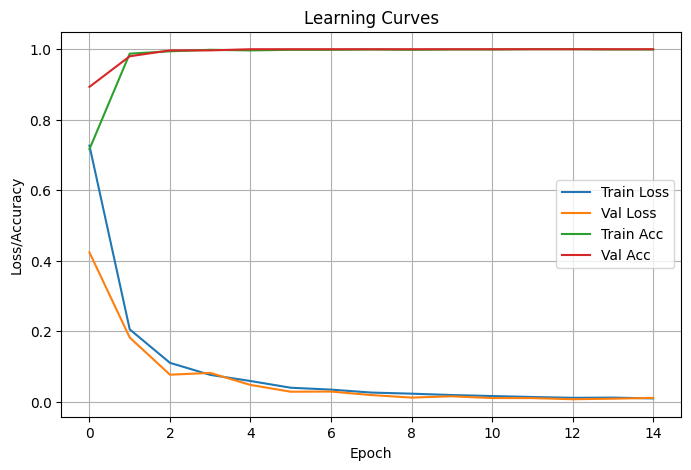

In [22]:
from tensorflow import keras

model = build_handnet_keras(num_classes=num_classes, input_shape=(32, 32, 1))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

batch_size = 32
n_epochs = 15  # you can bump this if underfitting

history = model.fit(
    X_train_keras,
    y_train,
    validation_data=(X_test_keras, y_test),
    batch_size=batch_size,
    epochs=n_epochs,
    shuffle=True,
)

test_loss, test_acc = model.evaluate(X_test_keras, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")

# Save weights for reuse (Keras 3 requires .weights.h5)
model.save_weights("handnet_keras_phase2_cropped.weights.h5")
print("Saved Keras weights to handnet_keras_phase2_cropped.weights.h5")
import matplotlib.pyplot as plt

# Plot learning curves
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.plot(history.history.get("accuracy", []), label="Train Acc")
plt.plot(history.history.get("val_accuracy", []), label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Loss/Accuracy")
plt.title("Learning Curves")
plt.legend()
plt.grid(True)
plt.show()




In [23]:
import tensorflow as tf
from tensorflow import keras

# ============================================================
# Export TFLite Model (Phase2 data with center cropping)
# ============================================================
# This model expects 64x64 grayscale input after cropping
# Cropping matches ESP32 preprocessing (17% left/right, 13px top/bottom)
# ============================================================

# Rebuild and load trained weights
model = build_handnet_keras(num_classes=num_classes, input_shape=(32, 32, 1))
model.load_weights("handnet_keras_phase2_cropped.weights.h5")
print("Loaded trained weights from handnet_keras_phase2_cropped.weights.h5")

saved_model_dir = "handnet_saved_model_keras"
model.export(saved_model_dir)
print("Exported SavedModel to", saved_model_dir)

converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
tflite_fp32_model = converter.convert()

with open("handnet_fp32.tflite", "wb") as f:
    f.write(tflite_fp32_model)

print("Exported FP32 TFLite to handnet_fp32.tflite (trained on Phase2 cropped data)")


Loaded trained weights from handnet_keras_phase2_cropped.weights.h5
Saved artifact at 'handnet_saved_model_keras'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 1), dtype=tf.float32, name='keras_tensor_98')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2359882894032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2359902071760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2359902070608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2359902071568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2359902069840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2359902073488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2359902071952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2359906067152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2359902076368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2359902073680: TensorSpe

In [24]:
import numpy as np
import tensorflow as tf

# ============================================================
# Quantize to INT8 for ESP32 Deployment (Phase2 cropped data)
# ============================================================
# INT8 quantization reduces model size ~4x for ESP32-S3
# Uses representative dataset from training data for calibration
# ============================================================

fp32_tflite_path = "handnet_fp32.tflite"
int8_tflite_path = "handnet_int8.tflite"

# Representative dataset from training data
def representative_data_gen():
    num_samples = 200
    count = 0
    for i in range(len(X_train_keras)):
        x = X_train_keras[i]  # [32, 32, 1]
        x_np = np.expand_dims(x, 0).astype(np.float32)  # [1, 32, 32, 1]
        yield [x_np]
        count += 1
        if count >= num_samples:
            return

converter = tf.lite.TFLiteConverter.from_saved_model("handnet_saved_model_keras")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

int8_tflite_model = converter.convert()

with open(int8_tflite_path, "wb") as f:
    f.write(int8_tflite_model)

print("Saved INT8 TFLite model to", int8_tflite_path, "(trained on Phase2 cropped data)")


Saved INT8 TFLite model to handnet_int8.tflite (trained on Phase2 cropped data)


In [25]:
import os
import numpy as np
import tensorflow as tf

fp32_tflite_path = "handnet_fp32.tflite"
int8_tflite_path = "handnet_int8.tflite"

fp32_size = os.path.getsize(fp32_tflite_path)
int8_size = os.path.getsize(int8_tflite_path)
print(f"FP32 TFLite size: {fp32_size} bytes")
print(f"INT8 TFLite size: {int8_size} bytes")

def eval_tflite_model(tflite_path, X, y, int8=False):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_index = input_details[0]["index"]
    output_index = output_details[0]["index"]

    correct = 0
    total = 0

    for i in range(len(X)):
        x_np = X[i]  # [64, 64, 1]
        x_np = np.expand_dims(x_np, 0).astype(np.float32)  # [1, 64, 64, 1]

        if int8:
            scale, zero_point = input_details[0]["quantization"]
            x_q = x_np / scale + zero_point
            x_q = np.clip(x_q, -128, 127).astype(np.int8)
            interpreter.set_tensor(input_index, x_q)
        else:
            interpreter.set_tensor(input_index, x_np)

        interpreter.invoke()
        logits = interpreter.get_tensor(output_index)[0]  # [num_classes]

        if int8:
            logits = logits.astype(np.float32)

        pred = int(np.argmax(logits))
        if pred == int(y[i]):
            correct += 1
        total += 1

    return 100.0 * correct / total

fp32_acc = eval_tflite_model(fp32_tflite_path, X_test_keras, y_test, int8=False)
print(f"FP32 TFLite test accuracy: {fp32_acc:.2f}%")

int8_acc = eval_tflite_model(int8_tflite_path, X_test_keras, y_test, int8=True)
print(f"INT8 TFLite test accuracy: {int8_acc:.2f}%")


FP32 TFLite size: 27652 bytes
INT8 TFLite size: 11496 bytes
FP32 TFLite test accuracy: 100.00%
INT8 TFLite test accuracy: 100.00%


c:\Users\austi\SpotifyGesture\HandSignalDetection\Model_Training\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Creating augmented test datasets...
Original test set size: 300
✓ Created noisy test set (noise_factor=0.15)
✓ Created rotated test set (±15 degrees)
✓ Created combined (noise + rotation) test set

EVALUATION RESULTS

1. Original Test Set (Clean Images):
   FP32 TFLite: 100.00%
   INT8 TFLite: 100.00%

2. Noisy Test Set (Gaussian noise, σ=0.15):
   FP32 TFLite: 33.33%
   INT8 TFLite: 33.33%

3. Rotated Test Set (±15 degrees):
   FP32 TFLite: 100.00%
   INT8 TFLite: 100.00%

4. Combined Test Set (Noise + Rotation):
   FP32 TFLite: 33.33%
   INT8 TFLite: 33.33%

SUMMARY - Accuracy Drop Analysis

INT8 TFLite Model (Deployed on ESP32):
  Clean:              100.00%
  With Noise:         33.33% (Δ -66.67%)
  With Rotation:      100.00% (Δ +0.00%)
  With Both:          33.33% (Δ -66.67%)

FP32 TFLite Model:
  Clean:              100.00%
  With Noise:         33.33% (Δ -66.67%)
  With Rotation:      100.00% (Δ +0.00%)
  With Both:          33.33% (Δ -66.67%)



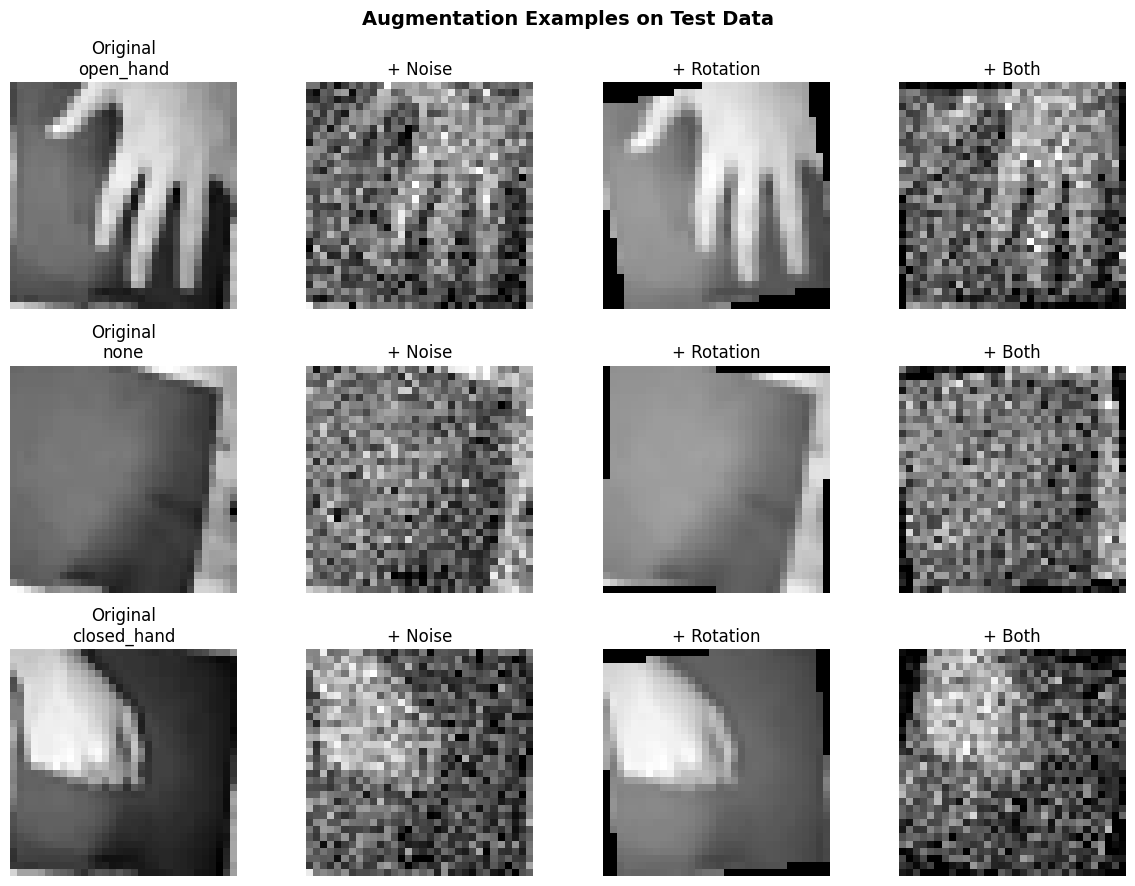


✓ Evaluation complete!


In [26]:
import numpy as np
import tensorflow as tf
from PIL import Image
from scipy.ndimage import rotate

# Function to add Gaussian noise
def add_noise(image, noise_factor=0.1):
    """Add Gaussian noise to image"""
    noise = np.random.normal(0, noise_factor, image.shape)
    noisy_image = image + noise
    noisy_image = np.clip(noisy_image, 0, 1)  # Keep values in [0, 1]
    return noisy_image.astype(np.float32)

# Function to rotate image
def rotate_image(image, angle):
    """Rotate image by specified angle (in degrees)"""
    # Remove channel dimension for rotation
    img_2d = image.squeeze()  # [64, 64]
    rotated = rotate(img_2d, angle, reshape=False, order=1, mode='constant', cval=0)
    # Add channel dimension back
    return rotated[..., np.newaxis].astype(np.float32)

# Create augmented test sets
print("Creating augmented test datasets...")
print(f"Original test set size: {len(X_test_keras)}")

# 1. Test set with noise
X_test_noisy = np.array([add_noise(img, noise_factor=0.15) for img in X_test_keras])
print(f"✓ Created noisy test set (noise_factor=0.15)")

# 2. Test set with rotation (±15 degrees randomly)
X_test_rotated = np.array([rotate_image(img, angle=np.random.uniform(-15, 15)) for img in X_test_keras])
print(f"✓ Created rotated test set (±15 degrees)")

# 3. Test set with both noise and rotation
X_test_both = np.array([
    add_noise(rotate_image(img, angle=np.random.uniform(-15, 15)), noise_factor=0.15) 
    for img in X_test_keras
])
print(f"✓ Created combined (noise + rotation) test set")

# Evaluation function
def eval_tflite_on_augmented(tflite_path, X, y, int8=False):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_index = input_details[0]["index"]
    output_index = output_details[0]["index"]

    correct = 0
    total = 0

    for i in range(len(X)):
        x_np = X[i]  # [64, 64, 1]
        x_np = np.expand_dims(x_np, 0).astype(np.float32)  # [1, 64, 64, 1]

        if int8:
            scale, zero_point = input_details[0]["quantization"]
            x_q = x_np / scale + zero_point
            x_q = np.clip(x_q, -128, 127).astype(np.int8)
            interpreter.set_tensor(input_index, x_q)
        else:
            interpreter.set_tensor(input_index, x_np)

        interpreter.invoke()
        logits = interpreter.get_tensor(output_index)[0]  # [num_classes]

        if int8:
            logits = logits.astype(np.float32)

        pred = int(np.argmax(logits))
        if pred == int(y[i]):
            correct += 1
        total += 1

    return 100.0 * correct / total

# Evaluate on all test sets
print("\n" + "="*60)
print("EVALUATION RESULTS")
print("="*60)

# Original test set (baseline)
print("\n1. Original Test Set (Clean Images):")
fp32_orig = eval_tflite_on_augmented(fp32_tflite_path, X_test_keras, y_test, int8=False)
int8_orig = eval_tflite_on_augmented(int8_tflite_path, X_test_keras, y_test, int8=True)
print(f"   FP32 TFLite: {fp32_orig:.2f}%")
print(f"   INT8 TFLite: {int8_orig:.2f}%")

# Noisy test set
print("\n2. Noisy Test Set (Gaussian noise, σ=0.15):")
fp32_noisy = eval_tflite_on_augmented(fp32_tflite_path, X_test_noisy, y_test, int8=False)
int8_noisy = eval_tflite_on_augmented(int8_tflite_path, X_test_noisy, y_test, int8=True)
print(f"   FP32 TFLite: {fp32_noisy:.2f}%")
print(f"   INT8 TFLite: {int8_noisy:.2f}%")

# Rotated test set
print("\n3. Rotated Test Set (±15 degrees):")
fp32_rotated = eval_tflite_on_augmented(fp32_tflite_path, X_test_rotated, y_test, int8=False)
int8_rotated = eval_tflite_on_augmented(int8_tflite_path, X_test_rotated, y_test, int8=True)
print(f"   FP32 TFLite: {fp32_rotated:.2f}%")
print(f"   INT8 TFLite: {int8_rotated:.2f}%")

# Combined (noise + rotation)
print("\n4. Combined Test Set (Noise + Rotation):")
fp32_both = eval_tflite_on_augmented(fp32_tflite_path, X_test_both, y_test, int8=False)
int8_both = eval_tflite_on_augmented(int8_tflite_path, X_test_both, y_test, int8=True)
print(f"   FP32 TFLite: {fp32_both:.2f}%")
print(f"   INT8 TFLite: {int8_both:.2f}%")

# Summary
print("\n" + "="*60)
print("SUMMARY - Accuracy Drop Analysis")
print("="*60)
print(f"\nINT8 TFLite Model (Deployed on ESP32):")
print(f"  Clean:              {int8_orig:.2f}%")
print(f"  With Noise:         {int8_noisy:.2f}% (Δ {int8_noisy - int8_orig:+.2f}%)")
print(f"  With Rotation:      {int8_rotated:.2f}% (Δ {int8_rotated - int8_orig:+.2f}%)")
print(f"  With Both:          {int8_both:.2f}% (Δ {int8_both - int8_orig:+.2f}%)")

print(f"\nFP32 TFLite Model:")
print(f"  Clean:              {fp32_orig:.2f}%")
print(f"  With Noise:         {fp32_noisy:.2f}% (Δ {fp32_noisy - fp32_orig:+.2f}%)")
print(f"  With Rotation:      {fp32_rotated:.2f}% (Δ {fp32_rotated - fp32_orig:+.2f}%)")
print(f"  With Both:          {fp32_both:.2f}% (Δ {fp32_both - fp32_orig:+.2f}%)")

print("\n" + "="*60)

# Visualize some augmented examples
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
fig.suptitle('Augmentation Examples on Test Data', fontsize=14, fontweight='bold')

# Show 3 random samples
sample_indices = np.random.choice(len(X_test_keras), 3, replace=False)

for row, idx in enumerate(sample_indices):
    # Original
    axes[row, 0].imshow(X_test_keras[idx].squeeze(), cmap='gray')
    axes[row, 0].set_title(f'Original\n{label_encoder.classes_[y_test[idx]]}')
    axes[row, 0].axis('off')
    
    # Noisy
    axes[row, 1].imshow(X_test_noisy[idx].squeeze(), cmap='gray')
    axes[row, 1].set_title('+ Noise')
    axes[row, 1].axis('off')
    
    # Rotated
    axes[row, 2].imshow(X_test_rotated[idx].squeeze(), cmap='gray')
    axes[row, 2].set_title('+ Rotation')
    axes[row, 2].axis('off')
    
    # Both
    axes[row, 3].imshow(X_test_both[idx].squeeze(), cmap='gray')
    axes[row, 3].set_title('+ Both')
    axes[row, 3].axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Evaluation complete!")
